In [1]:
import json
import os

import astropy.units as u
import cmasher
import gc_utils
import gizmo_analysis as gizmo
import h5py
import halo_analysis as halo
import matplotlib
import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import utilities as ut
from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import z_at_value
from astropy.io import ascii
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d, make_smoothing_spline
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from scipy.signal import savgol_filter
from scipy.stats import gaussian_kde, norm
from sklearn.mixture import GaussianMixture

# plt.rc("font", family="Nimbus Roman")
plt.rc("font", family="Nimbus Roman No9 L")

SMALL_SIZE = 10
MEDIUM_SIZE = 10
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title


In [2]:
# sim = "m12i"
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]

# sim_dir = "/Users/z5114326/Documents/simulations/"
sim_dir = "/Volumes/Expansion/simulations/"
sim_codes = sim_dir + "simulation_codes.json"
with open(sim_codes) as sim_json:
    sim_data = json.load(sim_json)

scmap = plt.get_cmap("tab10")
colors = [scmap(i) for i in np.linspace(0, 1, len(sim_lst))]
sim_colors = {sim: colors[i] for i, sim in enumerate(sim_lst)}

In [3]:
to_dict = {
    "m12b": {"cnt": 3.19, "mas": 3.19},
    "m12c": {"cnt": 4.43, "mas": 4.43},
    "m12f": {"cnt": 3.20, "mas": 3.20},
    "m12i": {"cnt": 5.19, "mas": 5.26},
    "m12m": {"cnt": 3.96, "mas": 4.60},
}

In [4]:
all_data_fil = sim_dir + "/" + "m12i" + "/" + "m12i" + "_res7100/" + "snapshot_times.txt"
all_data = pd.read_table(all_data_fil, comment="#", header=None, sep=r"\s+")
all_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
all_times = np.array(all_data["time_Gyr"])
all_snaps = np.array(all_data["index"])

public_snapshot_file = sim_dir + "snapshot_times_public.txt"
pub_data = pd.read_table(public_snapshot_file, comment="#", header=None, sep=r"\s+")
pub_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
timez0 = float(pub_data[pub_data["index"] == 600]["time_Gyr"].values[0])
pub_times = np.array(pub_data["time_Gyr"])
pub_snaps = np.array(pub_data["index"])

In [5]:
sim_dict = {sim: {"tims": None, "rats": None} for sim in sim_lst}

for sim in sim_lst:
    halt = gc_utils.get_halo_tree(sim, sim_dir)

    Ob = sim_data[sim]["Ob"]
    Om = sim_data[sim]["Om"]
    fb = Ob / Om

    halo_tid = sim_data[sim]["halo"]
    halo_tidx = np.where(halt["tid"] == halo_tid)[0][0]

    # nprog = halt["progenitor.number"][0]
    prog0 = halt["progenitor.main.index"][halo_tidx]
    all_progs = []
    snap_lst = []

    while prog0 > 0:
        snap_lst.append(halt["snapshot"][prog0] + 1)
        progs = [prog0]
        for prog in progs:
            prog_i = halt["progenitor.co.index"][prog]
            if prog_i > 0:
                progs.append(prog_i)
        all_progs.append(progs)
        prog0 = halt["progenitor.main.index"][progs[0]]

    tim_lst = all_times[snap_lst]

    dm_mass = []
    to_mass = []
    for progs in all_progs:
        pmsk = halt["am.phantom"][progs] == 0
        dm_mas = halt["mass"][progs][pmsk]
        to_mas = dm_mas / (1 - fb)

        dm_mass.append(dm_mas)
        to_mass.append(to_mas)

    rats = []
    for to_mas, progs in zip(to_mass, all_progs):
        if len(to_mas) == 1:
            rats.append(0)
        else:
            main_msk = halt["am.progenitor.main"][progs] == 1
            if sum(main_msk) > 1:
                raise Warning("Too many main progenitors")
            rat = np.sum(to_mas[~main_msk]) / np.sum(to_mas[main_msk])
            rats.append(rat)

    tim = np.array(tim_lst)
    snp = np.array(snap_lst)
    rats = np.array(rats)

    idx = np.argsort(tim)

    tim_sorted = tim[idx]
    snp_sorted = snp[idx]
    rats_sorted = rats[idx]

    sim_dict[sim]["tims"] = tim_sorted
    sim_dict[sim]["snps"] = snp_sorted
    sim_dict[sim]["rats"] = rats_sorted

    del halt

Retrieving Halo Tree.....................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [01:13<00:00, 73.22s/it]


In [6]:
t_min = 1

for sim in sim_lst:
    trim_msk = t_min <= sim_dict[sim]["tims"]
    sim_dict[sim]["tims_trim"] = sim_dict[sim]["tims"][trim_msk]
    sim_dict[sim]["rats_trim"] = sim_dict[sim]["rats"][trim_msk]

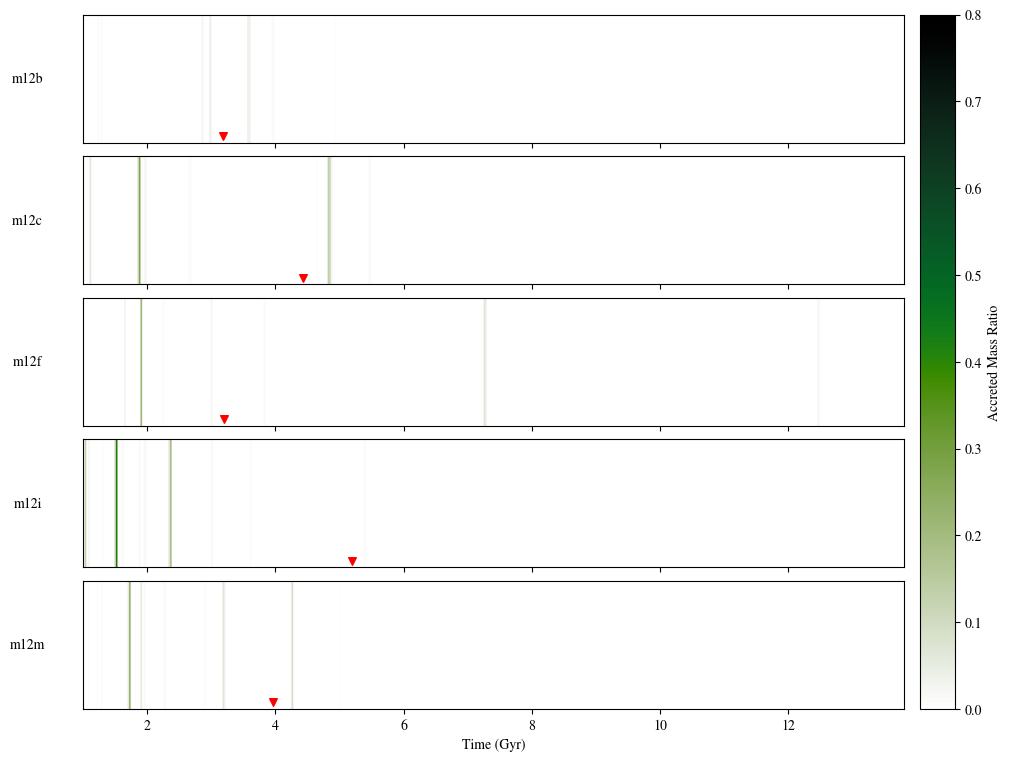

In [7]:
sims = list(sim_dict.keys())
n_sims = len(sims)

cmap = cmasher.jungle_r

fig, axes = plt.subplots(n_sims, 1, figsize=(10, 1.5 * n_sims), sharex=True, constrained_layout=True)

if n_sims == 1:
    axes = [axes]

# --- global linear color scale ---
# all_rats = np.concatenate([sim_dict[s]["rats_trim"] for s in sims])
vmin = 0
vmax = 0.8


# build a global time grid (shared across sims)
tmin = min(sim_dict[s]["tims_trim"].min() for s in sims)
tmax = max(sim_dict[s]["tims_trim"].max() for s in sims)

common_time = np.linspace(tmin, tmax, 500)  # increase resolution if needed


# --- plot ---
for ax, sim in zip(axes, sims):
    tim = sim_dict[sim]["tims_trim"]
    rats = sim_dict[sim]["rats_trim"]

    # interpolate
    rats_interp = np.interp(common_time, tim, rats, left=0, right=0)

    heat = rats_interp.reshape(1, -1)

    im = ax.imshow(
        heat,
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        extent=[common_time.min(), common_time.max(), 0, 1],
    )

    ax.set_yticks([])
    ax.set_ylabel(sim, rotation=0, labelpad=40, va="center")

    ax.scatter(to_dict[sim]["cnt"], 0.05, marker="v", color="red", s=30, zorder=3)

axes[-1].set_xlabel("Time (Gyr)")

# shared colorbar
cbar = fig.colorbar(im, ax=axes, pad=0.02)
cbar.set_label("Accreted Mass Ratio")


plt.show()


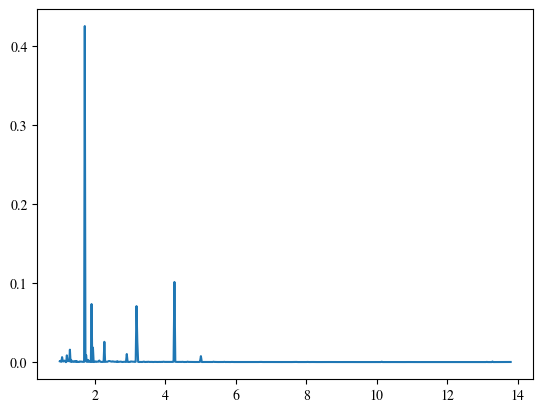

In [12]:
sim = "m12m"

plt.plot(sim_dict[sim]["tims_trim"], sim_dict[sim]["rats_trim"])

# Individual Galaxy Plots

In [17]:
def get_halo_center(part, halt, sim, sim_dir, snapshot):
    # check if centering should be on dm halo
    sim_codes = sim_dir + "simulation_codes.json"
    with open(sim_codes) as sim_json:
        sim_data = json.load(sim_json)
    main_halo_tid = sim_data[sim]["halo"]

    not_host_snap_lst = gc_utils.get_different_snap_lst(main_halo_tid, halt, sim, sim_dir)

    # is the MW progenitor is the main host at this snapshot
    is_main_host = snapshot not in not_host_snap_lst

    halt_center_snap_lst = sim_data[sim]["dm_center"]
    use_dm_center = snapshot in halt_center_snap_lst

    # if the halo is not the host at this snapshot or it has been flagged to use dm center at this snapshot
    if (not is_main_host) or (use_dm_center):
        # get MW progenitor halo details at this snapshot
        halo_tid = gc_utils.get_main_prog_at_snap(halt, main_halo_tid, snapshot)

        if use_dm_center:
            halo_detail_dict = gc_utils.get_dm_halo_details(part, halt, halo_tid, snapshot, True)
        else:
            halo_detail_dict = gc_utils.get_halo_details(part, halt, halo_tid, snapshot)

        return_dict = {"use_host_prop": False, "halo_details": halo_detail_dict}

    else:
        return_dict = {"use_host_prop": True}

    return return_dict


def get_mass_ratios(halt, part, sim: str, sim_dir: str, snapshot: int, r_50: float):
    host_return_dict = get_halo_center(part, halt, sim, sim_dir, snapshot)

    # stellar_mass
    if host_return_dict["use_host_prop"]:
        star_msk = part["star"].prop("host.distance.principal.total") < r_50
        dark_msk = part["dark"].prop("host.distance.principal.total") < r_50
    else:
        halo_detail_dict = host_return_dict["halo_details"]
        star_msk = (
            ut.particle.get_distances_wrt_center(
                part,
                species=["star"],
                center_position=halo_detail_dict["position"],
                rotation=halo_detail_dict["rotation"],
                coordinate_system="cartesian",
                total_distance=True,
            )
            < r_50
        )

        dark_msk = (
            ut.particle.get_distances_wrt_center(
                part,
                species=["dark"],
                center_position=halo_detail_dict["position"],
                rotation=halo_detail_dict["rotation"],
                coordinate_system="cartesian",
                total_distance=True,
            )
            < r_50
        )

    star_mass = part["star"]["mass"][star_msk]
    dark_mass = part["dark"]["mass"][dark_msk]

    return np.sum(star_mass) / np.sum(dark_mass)


This will take ages to run

In [18]:
mass_ratio_dict = {sim: {"tim": None, "msdm": None} for sim in sim_lst}

for sim in sim_lst:
    snap_lst = sim_dict[sim]["snps"]

    fire_dir = sim_dir + sim + "/" + sim + "_res7100"
    data_directory = sim_dir + sim + "/" + sim + "_res7100/"

    halt = gc_utils.get_halo_tree(sim, sim_dir, species=["star"])
    hals = halo.io.IO.read_catalogs("index", snap_lst, data_directory)

    snp_lst = pub_snaps[(pub_snaps > 45) & (pub_snaps <= 590)]
    tim_lst = pub_times[(pub_snaps > 45) & (pub_snaps <= 590)]
    host_tid = sim_data[sim]["halo"]

    r50s = []
    for snp in snp_lst:
        tid = gc_utils.get_halo_prog_at_snap(halt, host_tid, snp)
        idx = np.where(halt["tid"] == tid)[0][0]
        r50s.append(halt["star.radius.50"][idx])

    rats = []
    for snp, r50 in zip(snp_lst, r50s):
        part = gc_utils.open_snapshot(snp, fire_dir, ["star", "dark"])
        rat = get_mass_ratios(halt, part, sim, sim_dir, snp, r50)
        rats.append(rat)
        del part

    mass_ratio_dict[sim]["tim"] = tim_lst
    mass_ratio_dict[sim]["msdm"] = np.array(rats)

    cidxs = []
    for snp in snap_lst:
        tid = gc_utils.get_halo_prog_at_snap(halt, host_tid, snp)
        tidx = np.where(halt["tid"] == tid)[0][0]
        cidx = halt["catalog.index"][tidx]
        cidxs.append(cidx)

    stellar_disps = []
    stellar_dens = []
    for snap, cidx in zip(snap_lst, cidxs):
        hal = hals[snap]
        # star_disp = hal["star.vel.std.50"][cidx]
        # star_disp = hal.prop("star.age.50")[cidx]
        stellar_disps.append(hal["star.vel.std.50"][cidx])
        stellar_dens.append(hal.prop("star.density.50")[cidx])

    mass_ratio_dict[sim]["s_disp"] = np.array(stellar_disps)
    mass_ratio_dict[sim]["s_dens"] = np.array(stellar_dens)

    del halt
    del hals

Retrieving Snapshot 590..................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:54<00:00, 54.92s/it]


In [20]:
def to_json_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: to_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [to_json_serializable(v) for v in obj]
    elif isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    else:
        return obj


mass_ratio_dict_path = "../data/sim_data/mass_rat_dict.json"
if os.path.exists(mass_ratio_dict_path):
    print("Loading existing sim_halt_dict JSON...")
    with open(mass_ratio_dict_path, "r", encoding="utf-8") as f:
        mass_ratio_dict = json.load(f)

else:
    smass_ratio_dict_json = to_json_serializable(mass_ratio_dict)

    with open(mass_ratio_dict_path, "w", encoding="utf-8") as f:
        json.dump(smass_ratio_dict_json, f, indent=4)


Text(0, 0.5, 'log$(\\rho_\\star (r<r_50))$')

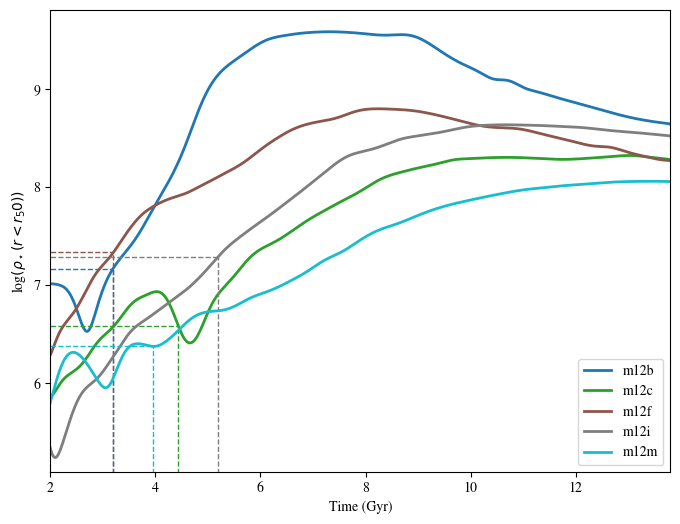

In [90]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))

for sim in sim_lst:
    stellar_dens_smooth = gaussian_filter1d(smass_ratio_dict_json[sim]["s_dens"], sigma=8)

    # plt.plot(sim_dict[sim]["tims"], np.log10(stellar_dens))
    ax.plot(sim_dict[sim]["tims"], np.log10(stellar_dens_smooth), c=sim_colors[sim], lw=2, label=sim)
    # ax.axvline(to_dict[sim]["cnt"], c=sim_colors[sim], lw=1, ls="--")

    minidx = np.argmin(np.abs(sim_dict[sim]["tims"] - to_dict[sim]["cnt"]))
    xmin = 0
    xmax = to_dict[sim]["cnt"]
    ymin = 0
    ymax = np.log10(stellar_dens_smooth)[minidx]

    print(sim, xmax, ymax)

    ax.plot([xmax, xmax], [0, ymax], c=sim_colors[sim], lw=1, ls="--")
    ax.plot([0, xmax], [ymax, ymax], c=sim_colors[sim], lw=1, ls="--")

ax.set_xlim(2, 13.8)
ax.set_ylim(5.1, 9.8)

ax.legend(loc="lower right")

ax.set_xlabel("Time (Gyr)")
ax.set_ylabel(r"log$(\rho_\star (r<r_50))$")

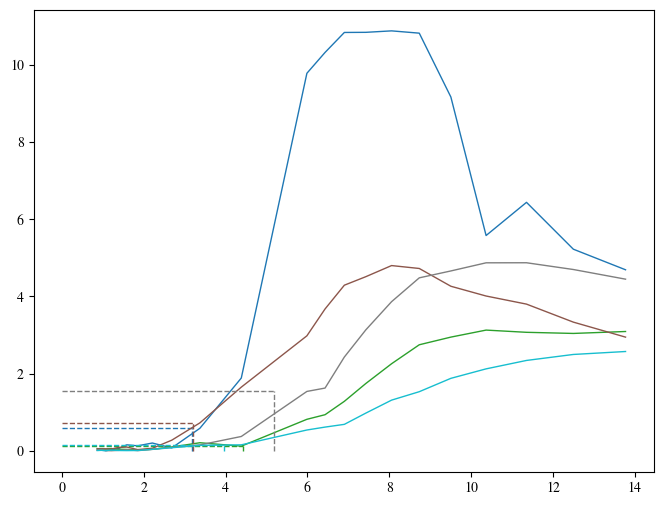

In [86]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))

for sim in sim_lst:
    # stellar_dens_smooth = gaussian_filter1d(smass_ratio_dict_json[sim]["s_dens"], sigma=8)

    # plt.plot(sim_dict[sim]["tims"], np.log10(stellar_dens))
    ax.plot(
        smass_ratio_dict_json[sim]["tim"],
        smass_ratio_dict_json[sim]["msdm"],
        c=sim_colors[sim],
        lw=1,
        label=sim,
    )
    # ax.axvline(to_dict[sim]["cnt"], c=sim_colors[sim], lw=1, ls="--")

    minidx = np.argmin(np.abs(np.array(smass_ratio_dict_json[sim]["tim"]) - to_dict[sim]["cnt"]))
    xmin = 0
    xmax = to_dict[sim]["cnt"]
    ymin = 0
    ymax = smass_ratio_dict_json[sim]["msdm"][minidx]

    #     print(sim, xmax, ymax)

    ax.plot([xmax, xmax], [0, ymax], c=sim_colors[sim], lw=1, ls="--")
    ax.plot([0, xmax], [ymax, ymax], c=sim_colors[sim], lw=1, ls="--")

# ax.set_yscale("log")

# ax.set_xlim(0, 13.8)
# ax.set_ylim(5.1, 9.8)

# ax.legend(loc="lower right")

# ax.set_xlabel("Time (Gyr)")
# ax.set_ylabel(r"log$(\rho_\star (r<r_50))$")